In [1]:
import torch
import numpy as np
import sys
import matplotlib.pyplot as plt
sys.path.append("/home/548/cd3022/repos/CPDiT/")
from src_testing.petdata import build_dataloader
from src_testing.training.config import load_config

In [2]:
config = load_config("/home/548/cd3022/repos/CPDiT/configs/experimental_config.yaml")
loader = build_dataloader("train", config, shuffle=False)

timestamp: 2020-01-01T00:10:00.000000000
timestamp: 2020-01-01T00:20:00.000000000
timestamp: 2020-01-01T00:30:00.000000000
timestamp: 2020-01-01T00:40:00.000000000
No NANs in data
timestamp: 2020-01-01T00:50:00.000000000
timestamp: 2020-01-01T01:00:00.000000000
timestamp: 2020-01-01T01:10:00.000000000
timestamp: 2020-01-01T01:20:00.000000000
No NANs in data
timestamp: 2020-01-01T01:30:00.000000000
timestamp: 2020-01-01T01:40:00.000000000
timestamp: 2020-01-01T01:50:00.000000000
timestamp: 2020-01-01T02:00:00.000000000
No NANs in data
timestamp: 2020-01-01T02:10:00.000000000
timestamp: 2020-01-01T02:20:00.000000000
timestamp: 2020-01-01T02:30:00.000000000
timestamp: 2020-01-01T02:40:00.000000000
No NANs in data
timestamp: 2020-01-01T02:50:00.000000000
NANs found in tensor sample, skipping...
timestamp: 2020-01-01T03:00:00.000000000
NANs found in tensor sample, skipping...
timestamp: 2020-01-01T03:10:00.000000000
NANs found in tensor sample, skipping...
timestamp: 2020-01-01T03:20:00.000

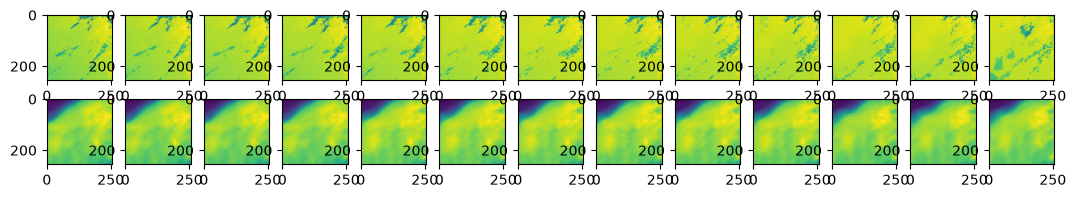

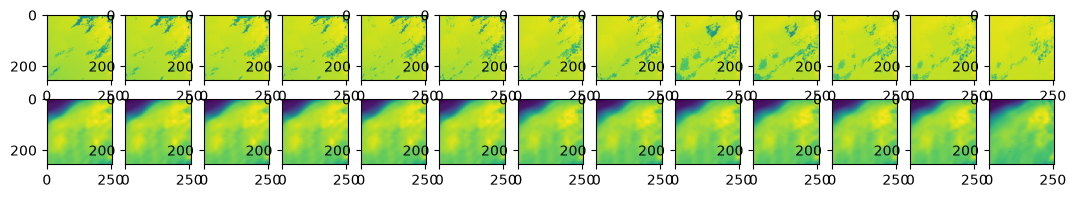

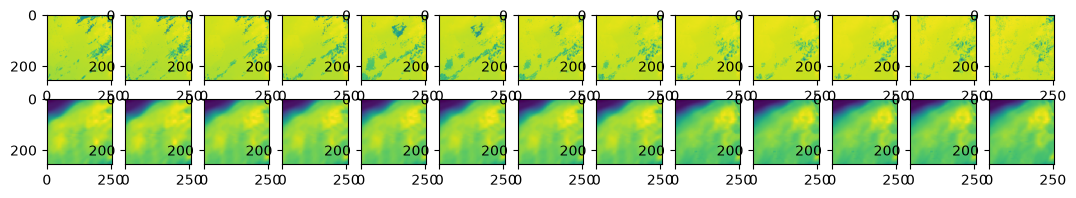

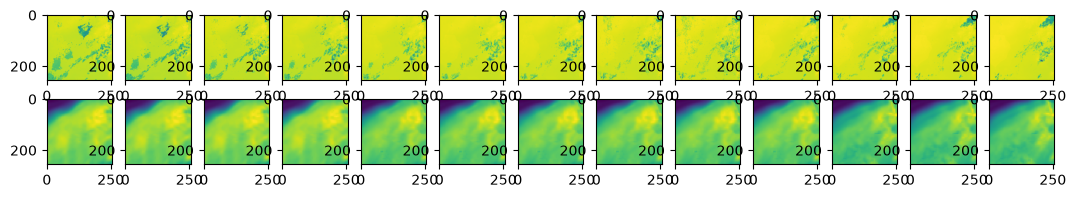

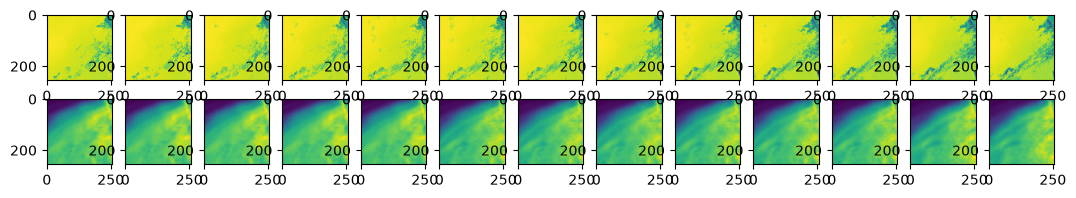

In [3]:
iterator = iter(loader)
n=0
for context, forecast in iterator:
    if n == 5:
        break
    # tensor = torch.tensor(sample, dtype=torch.float32)

    # Skip samples containing NaN or Inf (e.g. night-time masked pixels)
    if torch.any(torch.isnan(context)) or torch.any(torch.isnan(forecast)):
        print("NANs found, skipping")
        continue
    print("No NANs in data")
    # Join context and forecast into a single tesnor
    full_batch = torch.cat([context, forecast], dim=1)
    # Select just a single sample from the batch
    sample = full_batch[0,:,:,:,:]

    # plot dimensions
    nrows = sample.shape[1]
    ncols = sample.shape[0]
    figsize = (ncols, nrows)

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    for i in range (nrows):
        for j in range(ncols):
            ax[i,j].imshow(sample[j,i,:,:])
    n+=1